# 1. Импорт библиотек и функций

## 1.1. Библиотеки

In [1]:
import re
import string
import nltk
from nltk.corpus import stopwords
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

## 1.2. Функции

In [2]:
def plot_topic_barchart(df, topic_col = 'topic', figsize = (12, 6)):
    """
    Столбчатая диаграмма распределения тематических категорий
    """
    topic_counts = df[topic_col].value_counts().sort_values(ascending=False)

    plt.figure(figsize=figsize)
    bars = plt.bar(range(len(topic_counts)), topic_counts.values, 
                   color=plt.cm.Set3(np.linspace(0, 1, len(topic_counts))))
    
    plt.title('Распределение новостей по темам', fontsize=14, fontweight='bold')
    plt.ylabel('Количество новостей', fontsize=12)
    plt.xlabel('Темы', fontsize=12)
    plt.xticks(range(len(topic_counts)), topic_counts.index, rotation=45, ha='right')
    plt.grid(axis='y', alpha=0.3)
    
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + 0.01 * max(topic_counts.values),
                f'{int(height)}', ha='center', va='bottom', fontsize=9)
    
    plt.tight_layout()
    plt.show()

In [3]:
def plot_topic_timeseries(df, topic_col = 'topic', date_col = 'date', top_n = 4, figsize = (14, 6)):
    """
    Временной ряд публикаций по топ-N темам
    """
    df = df.copy()
    if not pd.api.types.is_datetime64_any_dtype(df[date_col]):
        df[date_col] = pd.to_datetime(df[date_col])
    
    top_topics = df[topic_col].value_counts().head(top_n).index
    
    topic_time_series = df[df[topic_col].isin(top_topics)].groupby(
        [df[date_col].dt.to_period('M'), topic_col]
    ).size().unstack().fillna(0)
    
    plt.figure(figsize=figsize)
    topic_time_series.plot(kind='line', marker='o', ax=plt.gca())
    plt.title(f'Динамика публикаций по темам', fontsize=14, fontweight='bold')
    plt.ylabel('Количество новостей в месяц')
    plt.xlabel('Дата')
    plt.legend(title='Темы', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

In [4]:
def plot_word_count_distribution(df, text_col = 'text', figsize = (10, 6)):
    """
    Распределение длины текста (слова)
    """
    df = df.copy()
    df['word_count'] = df[text_col].str.split().str.len()
    
    plt.figure(figsize=figsize)
    plt.hist(df['word_count'], bins=100, alpha=0.7, color='skyblue', edgecolor='black')
    plt.axvline(df['word_count'].mean(), color='red', linestyle='--', 
                label=f'Среднее: {df["word_count"].mean():.1f} слов')
    plt.title('Распределение длины текстов', fontweight='bold')
    plt.xlabel('Количество слов')
    plt.ylabel('Частота')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

In [5]:
def plot_daily_word_length_evolution(df, text_col = 'text', date_col = 'date', figsize = (12, 6)):
    """
    Динамика средней длины новостей (слова) по дням
    """
    df = df.copy()
    df['word_count'] = df[text_col].str.split().str.len()
    
    if not pd.api.types.is_datetime64_any_dtype(df[date_col]):
        df[date_col] = pd.to_datetime(df[date_col])
    
    daily_avg = df.groupby(df[date_col].dt.date)['word_count'].mean()
    
    plt.figure(figsize=figsize)
    plt.plot(daily_avg.index, daily_avg.values, linewidth=1)
    plt.title('Динамика средней длины новостей по дням', fontweight='bold')
    plt.xlabel('Дата')
    plt.ylabel('Среднее количество слов')
    plt.grid(True, alpha=0.3)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [6]:
def plot_news_count_distribution(df, date_col = 'date', figsize = (10, 6)):
    """
    Распределение количества новостей по дням
    """
    df = df.copy()
    
    if not pd.api.types.is_datetime64_any_dtype(df[date_col]):
        df[date_col] = pd.to_datetime(df[date_col])
    
    daily_counts = df.groupby(df[date_col].dt.date).size()
    
    plt.figure(figsize=figsize)
    plt.hist(daily_counts.values, bins=20, alpha=0.7, color='lightgreen', edgecolor='black')
    plt.axvline(daily_counts.mean(), color='red', linestyle='--', 
                label=f'Среднее: {daily_counts.mean():.1f} новостей/день')
    plt.title('Распределение количества новостей по дням', fontweight='bold')
    plt.xlabel('Количество новостей в день')
    plt.ylabel('Частота (количество дней)')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

In [7]:
def plot_daily_news_count_evolution(df, date_col = 'date', figsize = (12, 6)):
    """
    Динамика количества новостей по дням
    """
    df = df.copy()
    
    if not pd.api.types.is_datetime64_any_dtype(df[date_col]):
        df[date_col] = pd.to_datetime(df[date_col])
    
    daily_counts = df.groupby(df[date_col].dt.date).size()
    
    plt.figure(figsize=figsize)
    plt.plot(daily_counts.index, daily_counts.values, linewidth=1)
    plt.title('Динамика количества новостей по дням', fontweight='bold')
    plt.xlabel('Дата')
    plt.ylabel('Количество новостей')
    plt.grid(True, alpha=0.3)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [8]:
def plot_top_words(df, text_col = 'text', top_n = 20, figsize = (12, 8)):
    """
    График топ-N самых частых слов в новостях
    """
    stop_words = set(stopwords.words('russian'))
    
    all_text = ' '.join(df[text_col].astype(str))
    words = re.findall(r'\b[а-яё]{3,}\b', all_text.lower())
    words = [word for word in words if word not in stop_words]
    
    word_freq = Counter(words)
    top_words = word_freq.most_common(top_n)
    words_df = pd.DataFrame(top_words, columns=['word', 'frequency'])
    
    plt.figure(figsize=figsize)
    bars = plt.barh(words_df['word'], words_df['frequency'], color='lightcoral', edgecolor='black')
    plt.title(f'Топ-{top_n} самых частых слов в новостях', fontweight='bold', fontsize=14)
    plt.xlabel('Частота')
    plt.ylabel('Слова')
    plt.gca().invert_yaxis()
    
    for i, freq in enumerate(words_df['frequency']):
        plt.text(freq + max(words_df['frequency']) * 0.01, i, str(freq), 
                va='center', fontsize=10)
    
    plt.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()

# 2. Приведение данных к общему виду

In [9]:
pd.set_option('display.max_colwidth', None)
pd.set_option('display.expand_frame_repr', False)

In [10]:
start_date = '2022-05-01'
end_date = '2025-10-01'

In [11]:
df_interfax = pd.read_csv('data/news_interfax.csv').drop('url', axis = 1).rename(columns = {'datetime': 'date', 'full_text': 'text', 'title': 'heading'})
df_interfax = df_interfax[(df_interfax['date'] >= start_date) & (df_interfax['date'] <= end_date)].reset_index(drop = True)
df_interfax['text'] = df_interfax['text'].str.split('\n').str[1:].str.join(' ')
df_interfax['text'] = df_interfax['text'].str.split('INTERFAX.RU - ').str[1]
df_interfax = df_interfax[['date', 'text', 'heading']]
df_interfax.head()

,date,text,heading
0,2022-05-01 09:43:00,"Активы представителей бизнеса из недружественных стран, расположенные в России, правильно будет конфисковать, заявил спикер Госдумы Вячеслав Володин. ""Правильно в отношении находящегося на территории Российской Федерации бизнеса, владельцы которого из недружественных стран, где принимаются подобные решения, отвечать зеркальными мерами: конфисковывать эти активы. А вырученные от продажи средства направить на развитие нашей страны"", - написал Володин в своём телеграм-канале в воскресенье. Он напомнил, что ранее палата представителей США приняла закон, разрешающий передачу Украине замороженных активов российских компаний и граждан. ""На экономику нашей страны это решение не повлияет. Изъятые яхты, виллы и другая собственность состоятельных граждан и так не работали на ее развитие"", - отметил Володин. Также он напомнил, что заморожены российские золотовалютные резервы на сумму порядка $300 млрд. ""Вернут, никуда не денутся. Это средства государства"", - пишет спикер. Центробанк в качестве ответной меры запретил иностранным инвесторам выводить средства из российской финансовой системы. По некоторым оценкам, речь идёт о более чем $500 млрд, отметил Володин. ""Сегодня российские предприниматели покупают зарубежные компании, работающие в России, выкупают доли партнёров, которые хотят уйти с нашего рынка. Действуют цивилизованно. В соответствии с нормами международного права. Чего нельзя сказать в отношении ряда недружественных стран: Литвы, Латвии, Польши, да и тех же США, которые просто занимаются воровством"", - написал спикер Госдумы.",Володин предложил конфисковывать активы владельцев бизнеса из недружественных стран
1,2022-05-01 09:45:00,"Европейские импортеры российского газа резко увеличили заявки на поставку топлива ""Газпрома"" , дождавшись снижения контрактных цен. Большинство договоров имеют привязку к рыночному индексу ""на день вперед"" - его значение в апреле было на рекордном уровне около $1400 за тысячу кубометров, а в мае снизилось до $1100. В апреле, как и ранее в январе текущего года, покупатели минимизировали отбор газа по контрактам с внешними поставщиками, пытаясь найти более дешевую альтернативу на спотовом рынке. Приближение цен контрактов к котировкам спота автоматически увеличило импортные заявки. ""Газпром"" осуществляет подачу российского газа для транзита через территорию Украины в штатном режиме, в соответствии с подтвержденными заявками европейских потребителей - 97,2 млн куб. м на 1 мая"", - сообщил журналистам официальный представитель компании Сергей Куприянов. Как свидетельствуют данные ""Оператора ГТС Украины"", номинация на прокачку газа РФ в регион на 1 мая составляет 96,7 млн куб. м, заявка на 30 апреля была 69,6 млн куб. м. Польша, отвергнув новую систему оплаты российского газа и, соответственно, отказавшись от дальнейших поставок, теперь такой же объем получает не с Востока, а с Запада - с территории Германии. В воскресенье реверсный поток по газопроводу ""Ямал-Европа"" из ФРГ в Польшу остается на максимальном уровне 1,3 млн куб. м в час (около 31 млн куб. м в сутки), свидетельствуют данные газотранспортного оператора Gascade. Это как раз тот объем, который ранее Польша получала в России. Ситуация с производством электроэнергии за счет возобновляемых источников в Европе на этой неделе заметно ухудшилась. На прошлой неделе (с 18 по 24 апреля) ветряки обеспечили в среднем 17% выработки электроэнергии по ЕС, а за шесть дней текущей недели их вклад составляет лишь 8,8%, свидетельствуют данные ассоциации WindEurope. На десять дней вперед в Европе ожидается маловетреная или штилевая погода, что не дает шансов на исправление ситуации. Европа продолжает закачку газа в подземные хранилища. На данный момент резервы составляют 33%, рост за последние сутки - 0,26 процентных пункта, свидетельствуют данные ассоциации Gas Infrastructure Europe. Текущий уровень запасов в ПХГ Европы отстает от среднего за пять лет на 6 процентных пунктов. В апреле закачка сдерживала

In [12]:
df_vedomosti = pd.read_csv('data/news_vedomosti.csv').drop(['url', 'tags'], axis = 1).rename(columns = {'content': 'text'})
df_vedomosti['date'] = pd.to_datetime(df_vedomosti['date']).dt.tz_localize(None)
df_vedomosti['heading'] = df_vedomosti['text'].str.split('\n').str[0]
df_vedomosti['text'] = df_vedomosti['text'].str.split('\n').str[1:].str.join(' ')
df_vedomosti = df_vedomosti[(df_vedomosti['date'] >= start_date) & (df_vedomosti['date'] <= end_date)].reset_index(drop = True)
df_vedomosti.head()

,date,topic,text,heading
0,2022-05-01 13:27:05,economics,"За четыре месяца 2022 г. «Газпром» поставил в Китай на 60% больше газа по сравнению с аналогичным периодом прошлого года, сообщает пресс-служба российской энергетической компании. Экспорт газа в Китай по газопроводу «Сила Сибири» осуществляется в рамках двустороннего долгосрочного контракта между «Газпромом» и CNPC. «Объем поставок за первые четыре месяца 2022 г. превышает аналогичный показатель прошлого года почти на 60%», — заявили в компании в субботу. Экспорт в страны дальнего зарубежья снизился на 26,9% по сравнению с прошлым годом и составил 50,1 млрд куб. м. Поставки «Газпрома» из газотранспортной системы на внутренний рынок снизились на 3,7%, компания объясняет это теплой погодой в феврале, говорится в сообщении. По предварительным данным, в январе - апреле «Газпром», добыл 175,4 млрд куб. м газа, что на 2,5% меньше, чем в прошлом году. Компания также приводит данные Gas Infrastructure Europe, согласно которым на 29 апреля запасы газа в европейских ПХГ восполнены на 6,9 млрд куб. м. «Для выхода на уровень 90% заполненности хранилищ, продекларированный Европейским союзом как целевой, компаниям предстоит закачать еще около 56 млрд куб. м газа», — отмечает «Газпром». В конце апреля «Газпром» отчитался о рекордных прибылях за IV квартал и весь 2021 г. Компания заработала 2,09 трлн руб. чистой прибыли по МСФО против 135 млрд руб. годом ранее. Выручка монополии увеличилась на 62% и достигла 10,24 трлн руб., показатель EBITDA вырос за отчетный период в 1,5 раза до 3,69 трлн руб. Чистая выручка от продажи газа выросла на 85% до 5,7 трлн руб., а от продажи продуктов нефтегазопереработки – на 44% и составила 2,6 трлн руб.",«Газпром» заявил о наращивании поставок газа в Китай на 60%
1,2022-05-01 14:53:55,politics,"Президент России Владимир Путин подписал закон о приостановлении действия отдельных положений договоров России с Евросоюзом, Данией, Норвегией, Лихтенштейном, Исландией и Швейцарией об упрощенной выдаче виз. Документ опубликован в воскресенье на официальном портале правовой информации. Упрощенный порядок выдачи виз приостанавливается «в связи с необходимостью принятия безотлагательных мер на недружественные действия» европейских стран, следует из текста закона. Как поясняет ТАСС, документ отменяет упрощенный порядок подачи документов и выдачи многократных виз на один год для официальных делегаций и журналистов, многократных виз на пять лет для членов национальных и региональных правительств, парламентов и судов. Также вновь действует требование об уплате визовых сборов для официальных делегаций и членов правительств и парламентов, отменяется безвизовый въезд владельцев дипломатических паспортов. В пояснительной записке сказано, что Россия «приостанавливает, а не прекращает действие отдельных положений международных договоров с указанными иностранными государствами». В начале апреля Путин подписал указ о введении ответных мер в отношении недружественных стран. Документ приостанавливает действие международных договоров об упрощении выдачи виз официальным лицам между Россией и ЕС, Норвегией, Данией, Исландией, Швейцарией и Лихтенштейном. Путин поручил МИД России направить уведомления о приостановлении договоров в посольства этих стран в Москве. Также президент поручил МИДу вместе с уполномоченными органами власти ввести ограничения на въезд в Россию и пребывание в ней граждан недружественных стран.",Путин подписал закон об отмене упрощенной выдачи виз для чиновников ЕС
2,2022-05-01 10:37:34,economics,"Процентная ставка по программе «Льготная ипотека» с 1 мая снижена с 12 до 9%, соответствующее постановление подписал председатель правительства Михаил Мишустин. Документом также продлевается действие программы до конца года, говорится на сайте кабмина. Решение позволит повысить доступность жилья для россиян и поддержать строительную отрасль, отмечают в правительстве. Параметры программы не изменились: льготная ипотека доступна при покупке квартир в новостройках, строит

In [13]:
df_kommersant = pd.read_csv('data/bad_news_kommersant.csv').drop('url', axis = 1)
df_kommersant['text'] = df_kommersant['text'].apply(lambda x: '.'.join(x.split('.')[:-2]) + '.')
df_kommersant = df_kommersant[(df_kommersant['date'] >= start_date) & (df_kommersant['date'] <= end_date)].reset_index(drop = True)
df_kommersant.head()

,date,topic,text,heading
0,2022-05-01 14:55:00,economics,"Президент России Владимир Путин подписал закон, который позволит поддержать финансовую стабильность региональных и местных бюджетов в условиях санкций, в том числе путем выделения новых кредитов из федерального бюджета и реструктуризации или списания старых. Документ опубликован на официальном портале правовой информации. Согласно закону, в 2022 году из федерального бюджета российские субъекты получат кредиты в общей сумме до 390,7 млрд руб. С помощью этих средств планируется погасить долговые обязательства регионов и муниципалитетов по государственным и муниципальным ценным бумагам и коммерческим кредитам, чей срок погашения приходится на март-декабрь. Кредиты со сроком погашения до 2029 года под 0,1% годовых предоставят регионам, чей показатель уровня расчетной бюджетной обеспеченности на текущий год не превышает 1,5%. Первоначально предусматривалось, что из федерального бюджета регионам направят до 255,3 млрд руб. на погашение только долговых обязательств. Однако депутаты Госдумы во втором чтении поддержали поправку, предусматривающую использование таких кредитов и на погашение аналогичных муниципальных обязательств. В связи с этим общий объем бюджетных кредитов, предоставляемых регионам на соответствующие цели, увеличили на 134,5 млрд руб. Также документом предусмотрено предоставление в текущем году «казначейских» кредитов (на пополнение остатка средств на едином счете бюджета) для регионов в размере, не превышающем 10% утвержденных доходов их бюджетов, и с возвратом не позднее 30 декабря 2022 года. Правительство установит порядок и условия предоставления таких кредитов. Кроме прочего, регионы в текущем году освободят от исполнения обязательств по ранее реструктурированной задолженности по бюджетным кредитам. Ее погашение было решено перенести на 2029 год. В текущем году может быть реструктурирована или списана правительством задолженность по ранее не реструктурированным бюджетным кредитам на частичное покрытие дефицитов региональных бюджетов, срок погашения которых наступает в текущем году. Реструктуризация предусматривает, что задолженность по основному долгу и процентам по таким кредитам в 2022 году погашению не подлежит. С 2023 по 2024 год погасят ежегодно по 5% суммы задолженности, а с 2025 по 2029 год — ежегодно равными долями от остатка задолженности с возможностью досрочного погашения. В закон была внесена поправка, предусматривающая перенос с текущего года на 2025 год погашения задолженности по основному долгу и процентам по бюджетным кредитам для Тамбовской и Псковской областей, Республики Марий Эл и Приморского края, что позволит регионам присоединиться к реструктуризации.",Путин подписал закон о дополнительной поддержке регионов в условиях санкций
1,2022-05-01 14:21:00,economics,"Президент России Владимир Путин подписал закон, облегчающий постановку иностранных организаций на налоговый учет при открытии счета в банке. Это среди прочего необходимо для оплаты поставок газа зарубежными компаниями в рублях. Поправки касаются условий регистрации в России иностранной холдинговой компании. Они облегчают процесс признания холдинговой компании, участники которой находятся под санкциями, вводят новое основание постановки иностранных организаций на налоговый учет — в связи с открытием счета в российском банке. Согласно действующему закону, эта обязанность была предусмотрена только для иностранных банков. Теперь она распространится на все зарубежные организации. Перечень документов, необходимых для предоставления в налоговый орган, будет определять Минфин.",Путин подписал закон об упрощении регистрации иностранных компаний
2,2022-05-01 01:34:00,economics,"С 1 мая малообеспеченные семьи могут подать заявление на получение новой выплаты на детей 8–17 лет. В мае нуждающиеся смогут получить выплату за апрель и май. Заявление можно подать через портал госуслуг. Форму досрочно открыли для заполнения с 26 апреля, с 1 мая заявки будут передаваться в Пенсионный фонд России. 

# 3. Анализ

## 3.1. Анализ новостей interfax

In [14]:
df_interfax.head(1)

,date,text,heading
0,2022-05-01 09:43:00,"Активы представителей бизнеса из недружественных стран, расположенные в России, правильно будет конфисковать, заявил спикер Госдумы Вячеслав Володин. ""Правильно в отношении находящегося на территории Российской Федерации бизнеса, владельцы которого из недружественных стран, где принимаются подобные решения, отвечать зеркальными мерами: конфисковывать эти активы. А вырученные от продажи средства направить на развитие нашей страны"", - написал Володин в своём телеграм-канале в воскресенье. Он напомнил, что ранее палата представителей США приняла закон, разрешающий передачу Украине замороженных активов российских компаний и граждан. ""На экономику нашей страны это решение не повлияет. Изъятые яхты, виллы и другая собственность состоятельных граждан и так не работали на ее развитие"", - отметил Володин. Также он напомнил, что заморожены российские золотовалютные резервы на сумму порядка $300 млрд. ""Вернут, никуда не денутся. Это средства государства"", - пишет спикер. Центробанк в качестве ответной меры запретил иностранным инвесторам выводить средства из российской финансовой системы. По некоторым оценкам, речь идёт о более чем $500 млрд, отметил Володин. ""Сегодня российские предприниматели покупают зарубежные компании, работающие в России, выкупают доли партнёров, которые хотят уйти с нашего рынка. Действуют цивилизованно. В соответствии с нормами международного права. Чего нельзя сказать в отношении ряда недружественных стран: Литвы, Латвии, Польши, да и тех же США, которые просто занимаются воровством"", - написал спикер Госдумы.",Володин предложил конфисковывать активы владельцев бизнеса из недружественных стран


In [15]:
df_interfax.duplicated().sum()

0

In [16]:
df_interfax.isna().sum()

date         0
text       274
heading      0
dtype: int64

In [17]:
df_interfax.dropna(inplace = True)

In [18]:
df_interfax.info()

<class 'pandas.core.frame.DataFrame'>
Index: 63067 entries, 0 to 63340
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   date     63067 non-null  object
 1   text     63067 non-null  object
 2   heading  63067 non-null  object
dtypes: object(3)
memory usage: 1.9+ MB


**Вывод:** В данных имелось немного пропусков, которые было принято решение удалить, дубликаты отстутствуют. Имеется проблема слипшихся слов в некоторых новостях из-за спецсимволов в источнике, но таких случаев мало. Данные имеют только экономические новости, поэтому колонка 'topic' отсутствует.

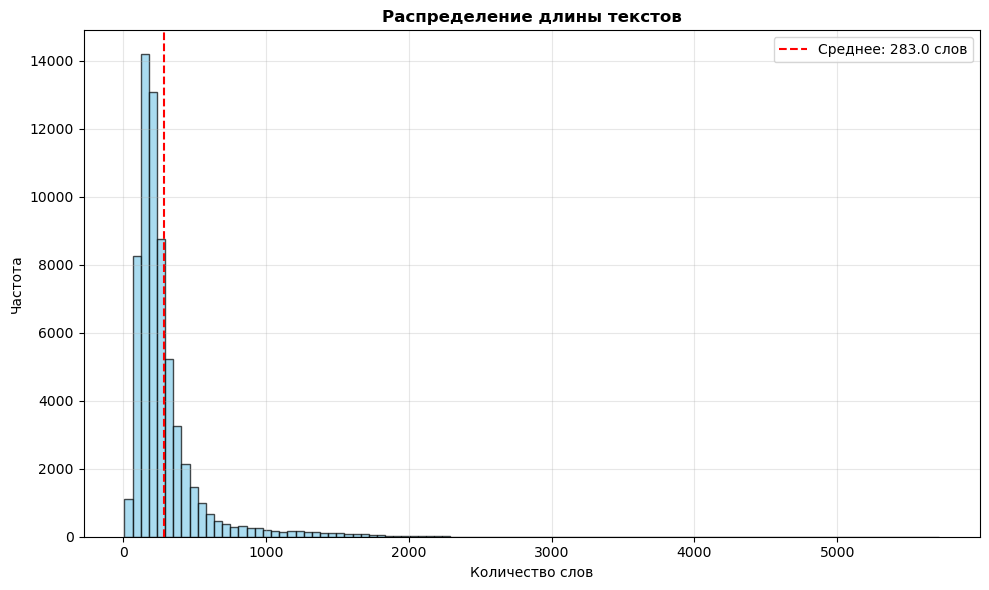

In [19]:
plot_word_count_distribution(df_interfax, 'text')

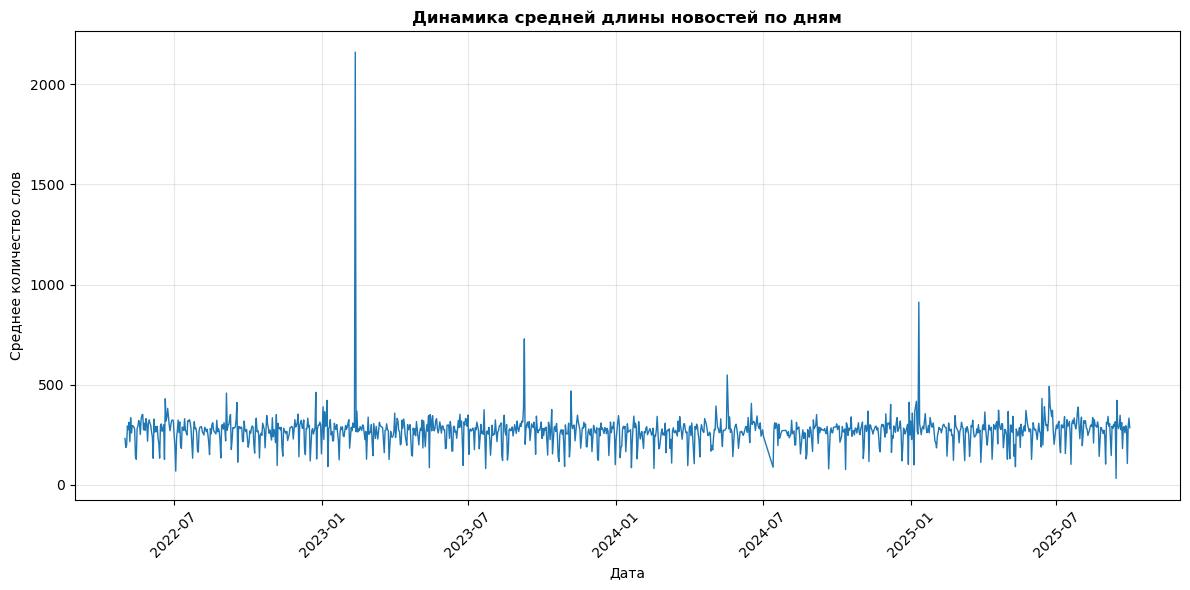

In [20]:
plot_daily_word_length_evolution(df_interfax, 'text', 'date')

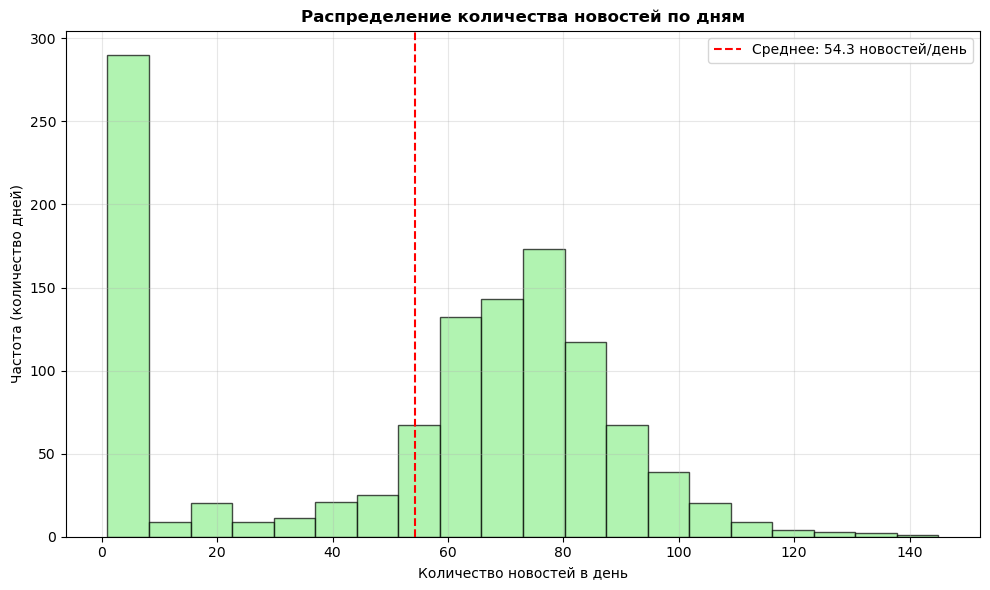

In [21]:
plot_news_count_distribution(df_interfax, 'date')

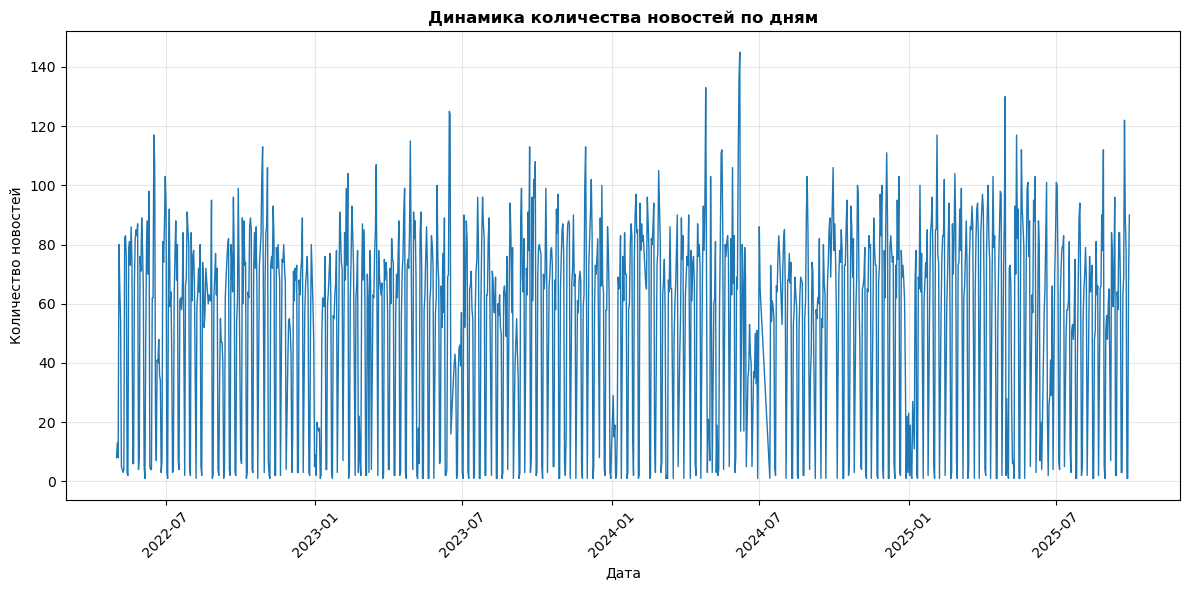

In [22]:
plot_daily_news_count_evolution(df_interfax, 'date')

**Вывод:** В данном источнике в среднем новости содержат около 280 слов. В целом, их длина стабильна, однако имеется немного аномально больших значений, которые было принято решение удалить из-за потенциальных трудностей работы с ними. Имеется много дней, где количество новостей очень близко к 0, что, возможно, говорит о непостоянстве источника.

In [23]:
df_interfax = df_interfax[df_interfax['text'].str.split().str.len() <= 1000].reset_index(drop = True)

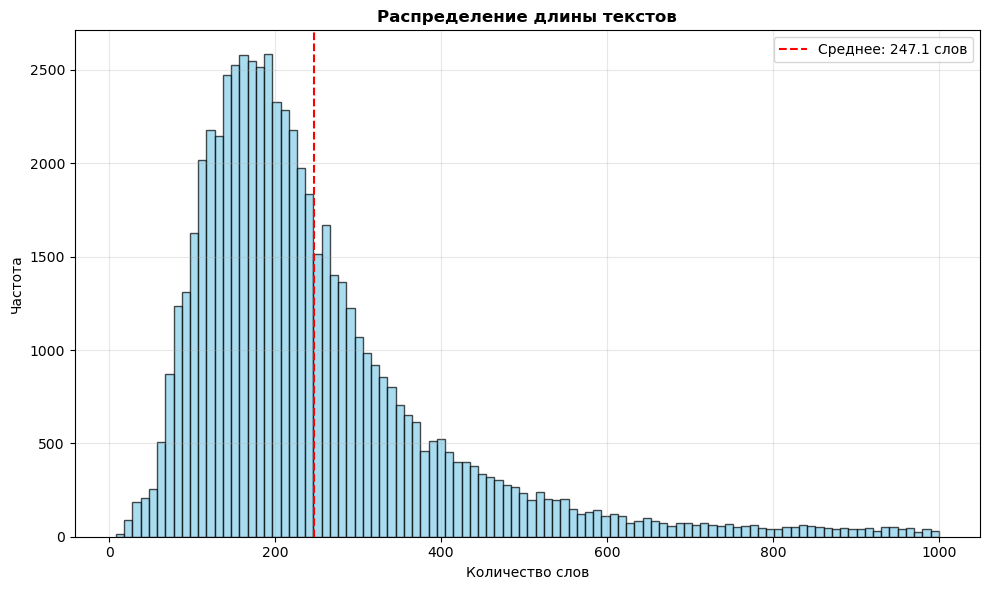

In [24]:
plot_word_count_distribution(df_interfax, 'text')

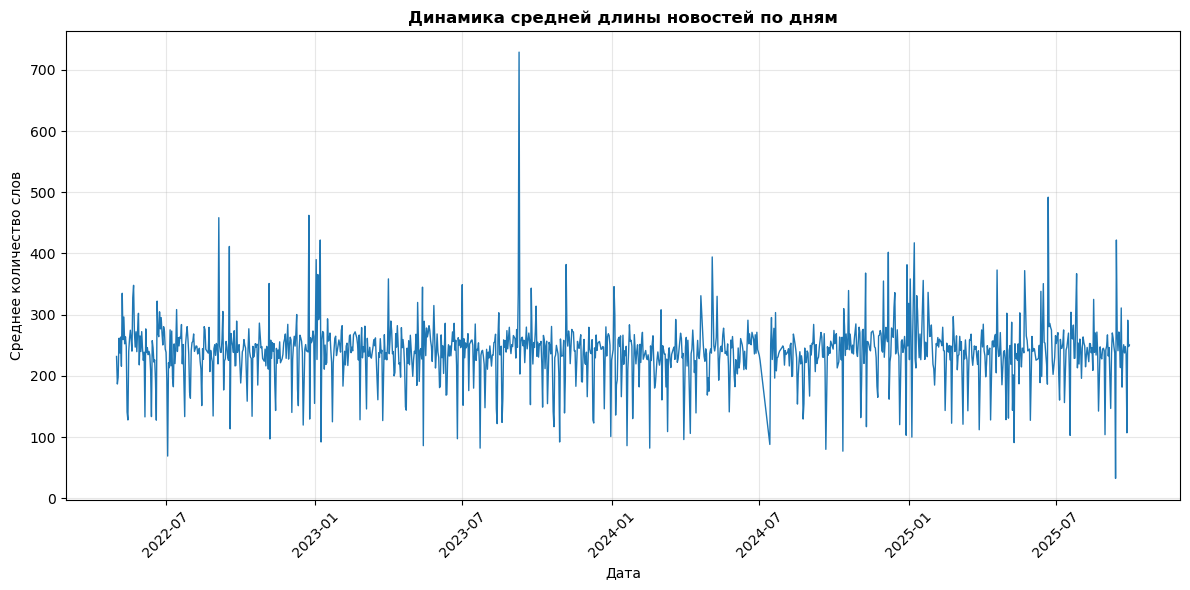

In [25]:
plot_daily_word_length_evolution(df_interfax, 'text', 'date')

**Вывод:** После удаления аномальных значений распределение и динамика заметно улучшились, средняя длина стала около 250 слов.

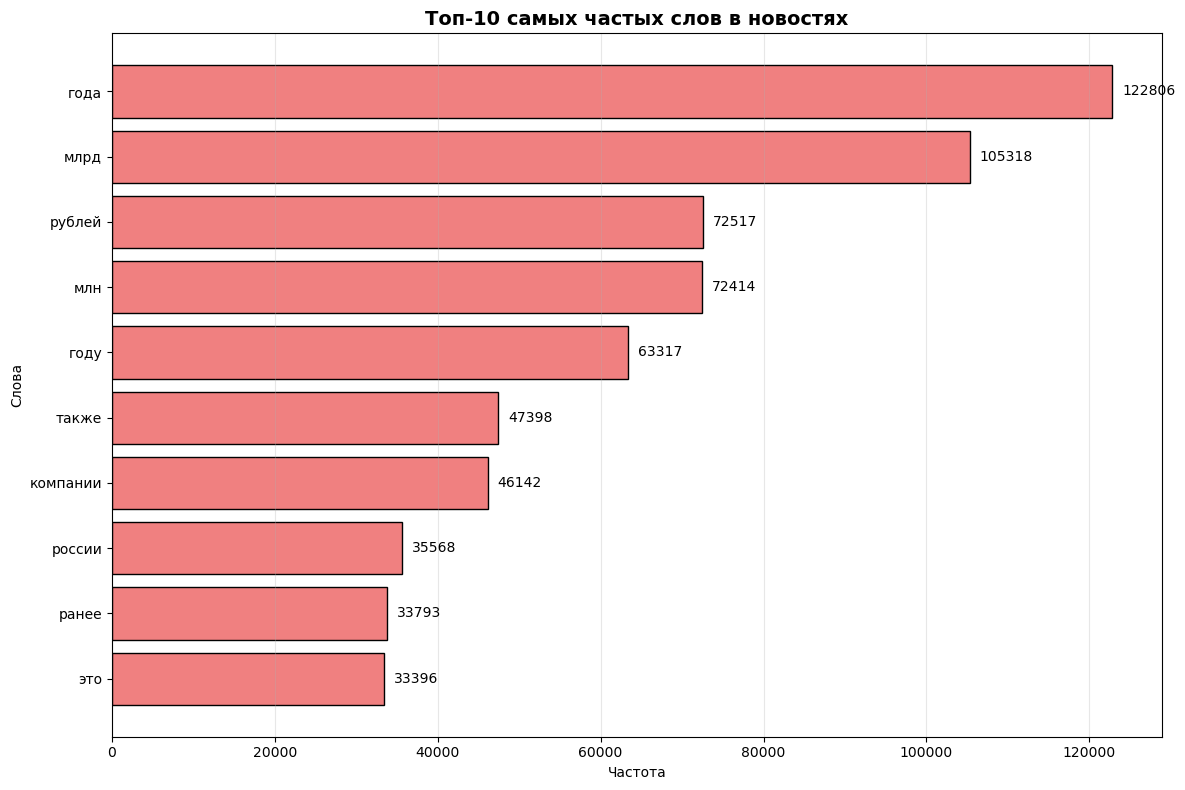

In [26]:
plot_top_words(df_interfax, 'text', top_n = 10)

## 3.2. Анализ новостей vedomosti

In [27]:
df_vedomosti.head(1)

,date,topic,text,heading
0,2022-05-01 13:27:05,economics,"За четыре месяца 2022 г. «Газпром» поставил в Китай на 60% больше газа по сравнению с аналогичным периодом прошлого года, сообщает пресс-служба российской энергетической компании. Экспорт газа в Китай по газопроводу «Сила Сибири» осуществляется в рамках двустороннего долгосрочного контракта между «Газпромом» и CNPC. «Объем поставок за первые четыре месяца 2022 г. превышает аналогичный показатель прошлого года почти на 60%», — заявили в компании в субботу. Экспорт в страны дальнего зарубежья снизился на 26,9% по сравнению с прошлым годом и составил 50,1 млрд куб. м. Поставки «Газпрома» из газотранспортной системы на внутренний рынок снизились на 3,7%, компания объясняет это теплой погодой в феврале, говорится в сообщении. По предварительным данным, в январе - апреле «Газпром», добыл 175,4 млрд куб. м газа, что на 2,5% меньше, чем в прошлом году. Компания также приводит данные Gas Infrastructure Europe, согласно которым на 29 апреля запасы газа в европейских ПХГ восполнены на 6,9 млрд куб. м. «Для выхода на уровень 90% заполненности хранилищ, продекларированный Европейским союзом как целевой, компаниям предстоит закачать еще около 56 млрд куб. м газа», — отмечает «Газпром». В конце апреля «Газпром» отчитался о рекордных прибылях за IV квартал и весь 2021 г. Компания заработала 2,09 трлн руб. чистой прибыли по МСФО против 135 млрд руб. годом ранее. Выручка монополии увеличилась на 62% и достигла 10,24 трлн руб., показатель EBITDA вырос за отчетный период в 1,5 раза до 3,69 трлн руб. Чистая выручка от продажи газа выросла на 85% до 5,7 трлн руб., а от продажи продуктов нефтегазопереработки – на 44% и составила 2,6 трлн руб.",«Газпром» заявил о наращивании поставок газа в Китай на 60%


In [28]:
df_vedomosti.duplicated().sum()

0

In [29]:
df_vedomosti.isna().sum()

date         0
topic        0
text       460
heading    460
dtype: int64

In [30]:
df_vedomosti.dropna(inplace = True)

In [31]:
df_vedomosti.info()

<class 'pandas.core.frame.DataFrame'>
Index: 37276 entries, 0 to 37735
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   date     37276 non-null  datetime64[ns]
 1   topic    37276 non-null  object        
 2   text     37276 non-null  object        
 3   heading  37276 non-null  object        
dtypes: datetime64[ns](1), object(3)
memory usage: 1.4+ MB


**Вывод:** В данных имелось немного пропусков, которые было принято решение удалить, дубликаты отстутствуют.

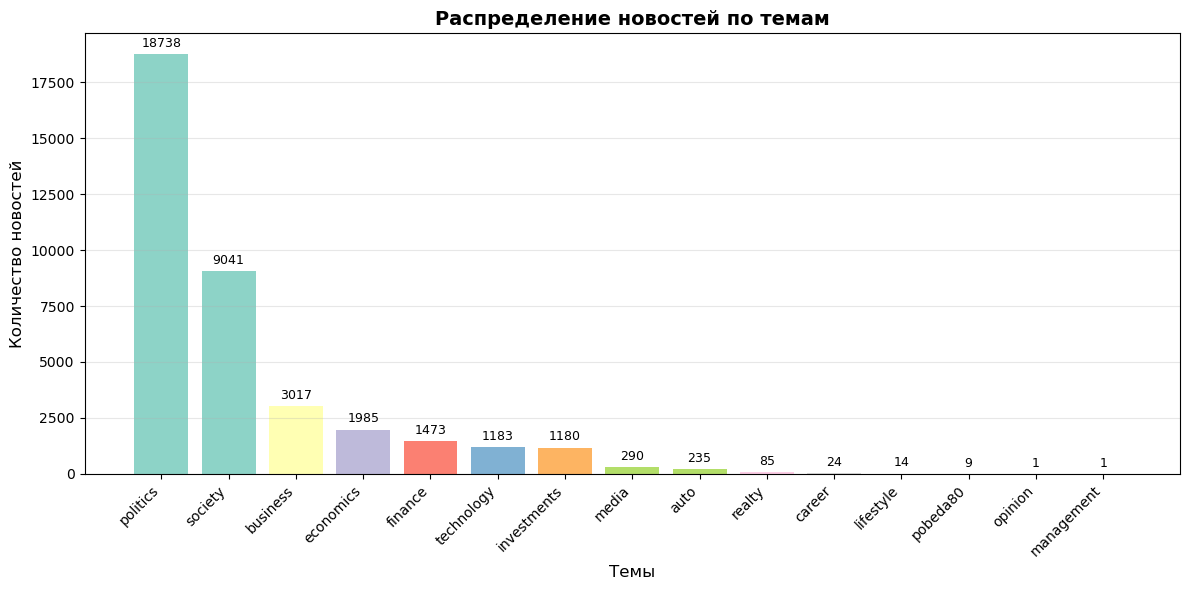

In [32]:
plot_topic_barchart(df_vedomosti, 'topic')

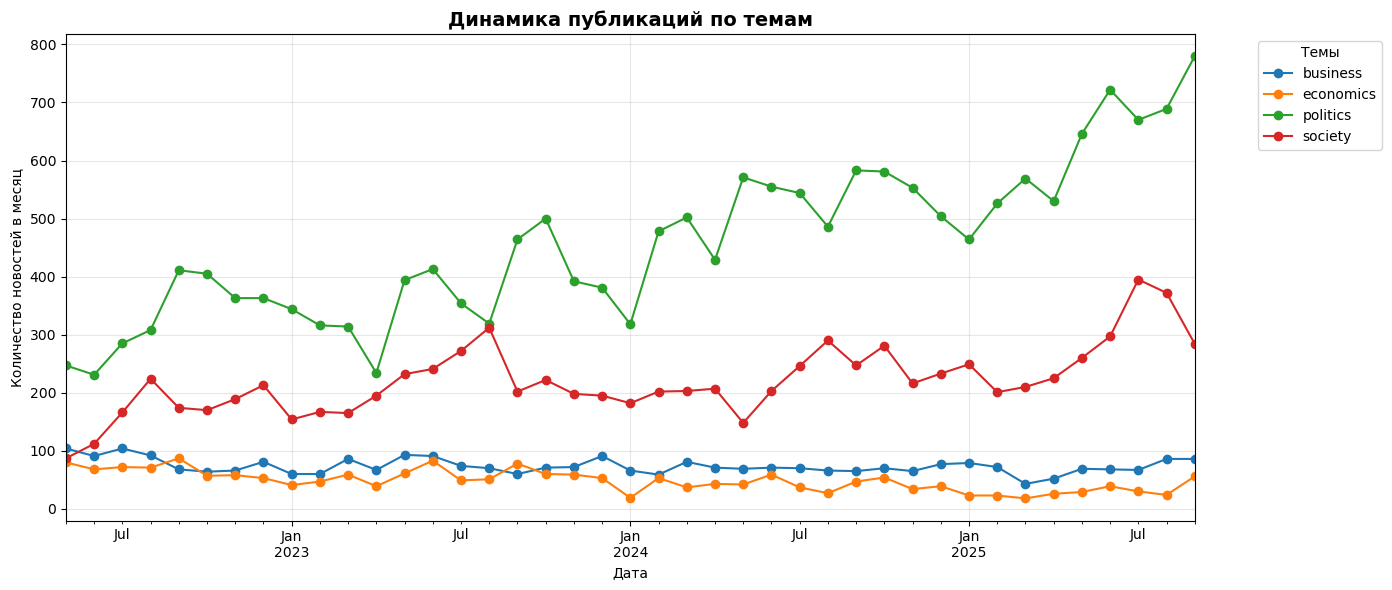

In [33]:
plot_topic_timeseries(df_vedomosti, 'topic', 'date', top_n = 4)

**Вывод:** В распределении тем сильный дисбаланс классов. Имеются темы, в которых очень мало новостей, поэтому было принято решение удалить 8 наименее информативных из них. Источник содержит в основном политические новости, количество публикаций которых постоянно увеличивается.

In [34]:
df_vedomosti = df_vedomosti[df_vedomosti['topic'].map(df_vedomosti['topic'].value_counts()) >= 1000].reset_index(drop = True)

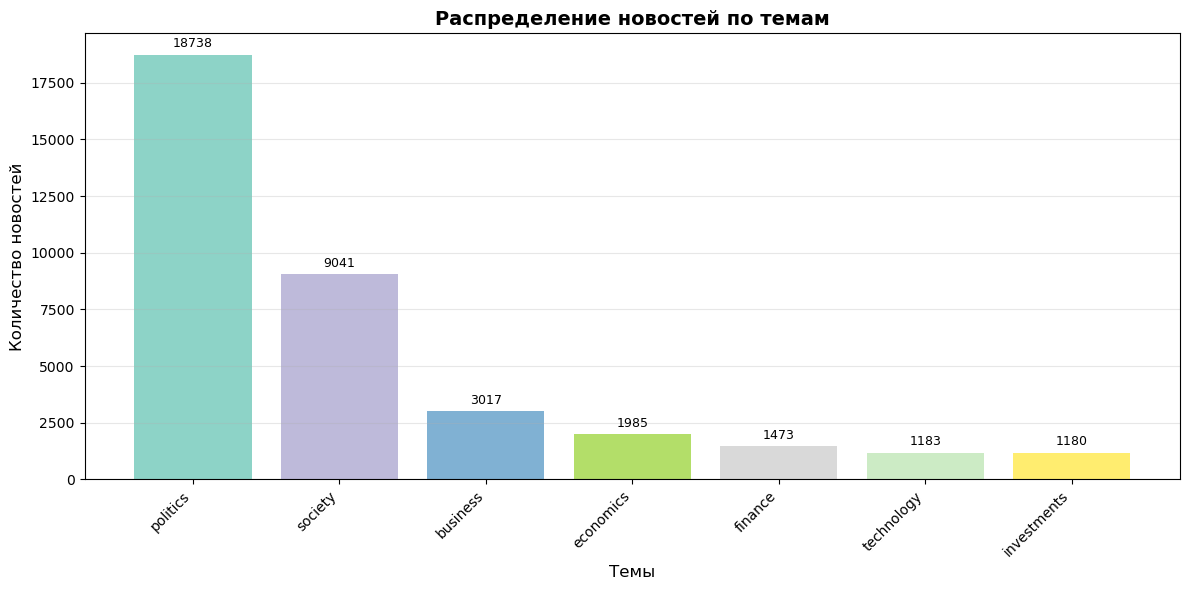

In [35]:
plot_topic_barchart(df_vedomosti, 'topic')

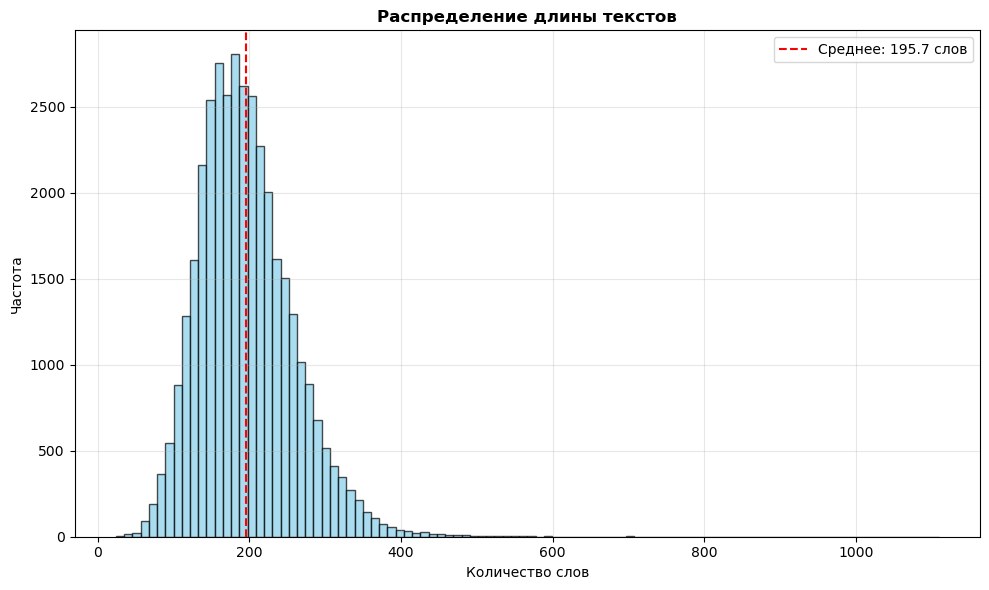

In [36]:
plot_word_count_distribution(df_vedomosti, 'text')

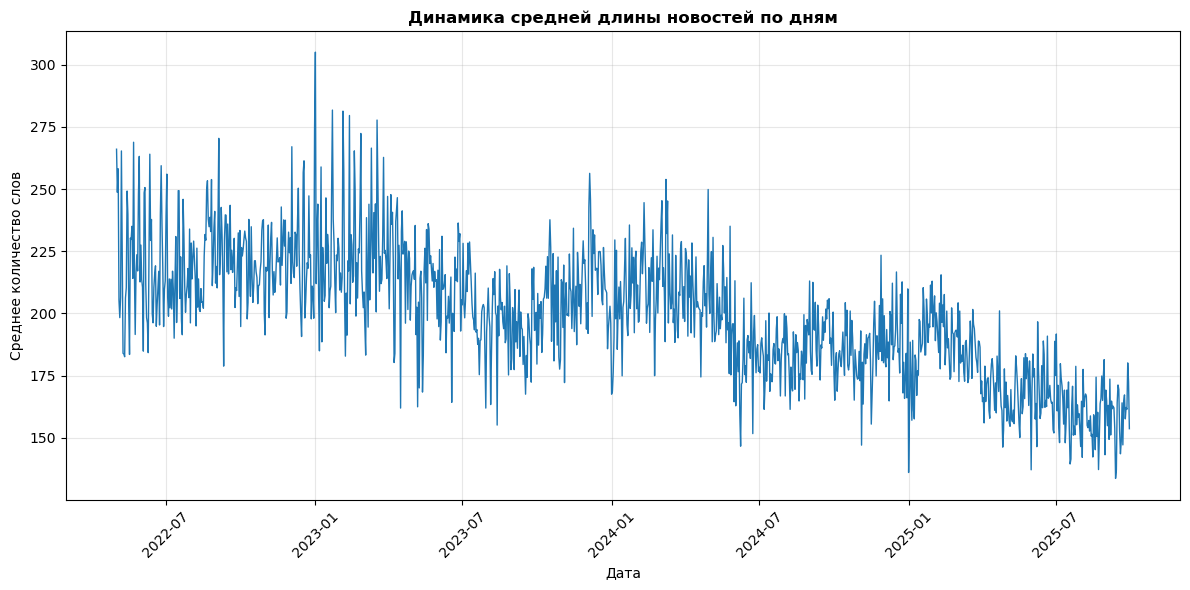

In [37]:
plot_daily_word_length_evolution(df_vedomosti, 'text', 'date')

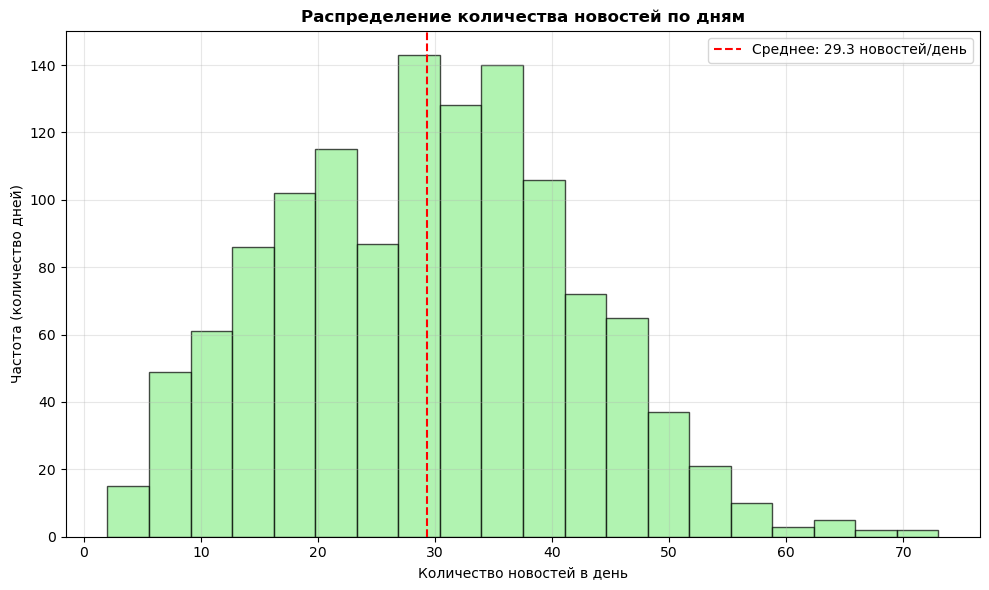

In [38]:
plot_news_count_distribution(df_vedomosti, 'date')

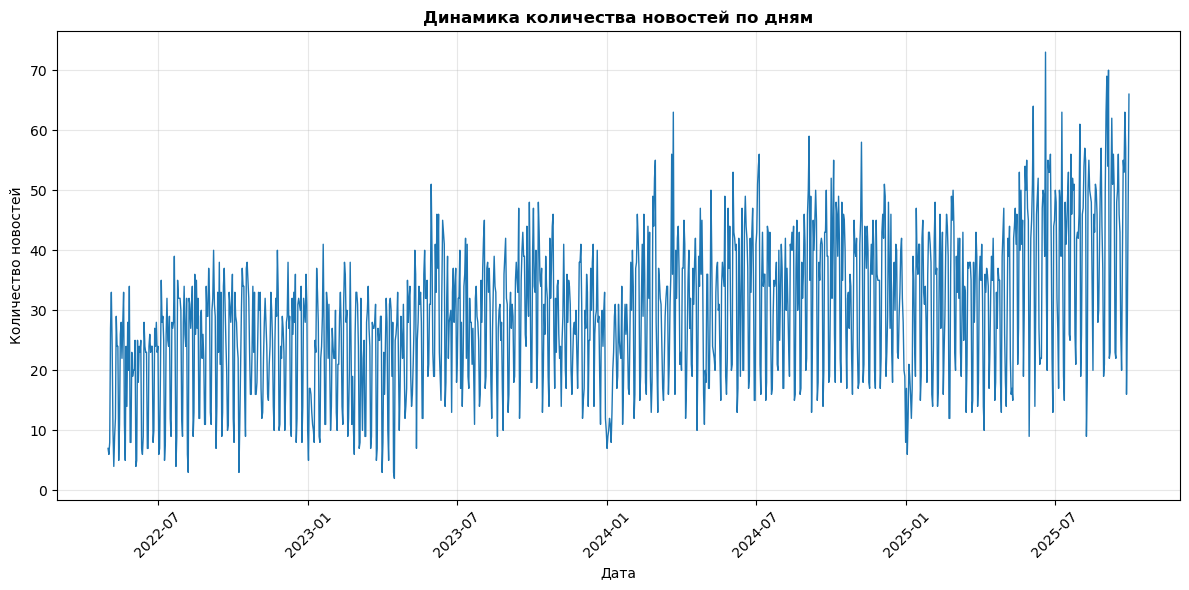

In [39]:
plot_daily_news_count_evolution(df_vedomosti, 'date')

**Вывод:** В данном источнике в среднем новости содержат около 200 слов. Их длина со временем уменьшается, а количество - увеличивается. В целом, источник можно назвать качественным, однако надо учитывать преобладание именно политических новостей для российского рынка.

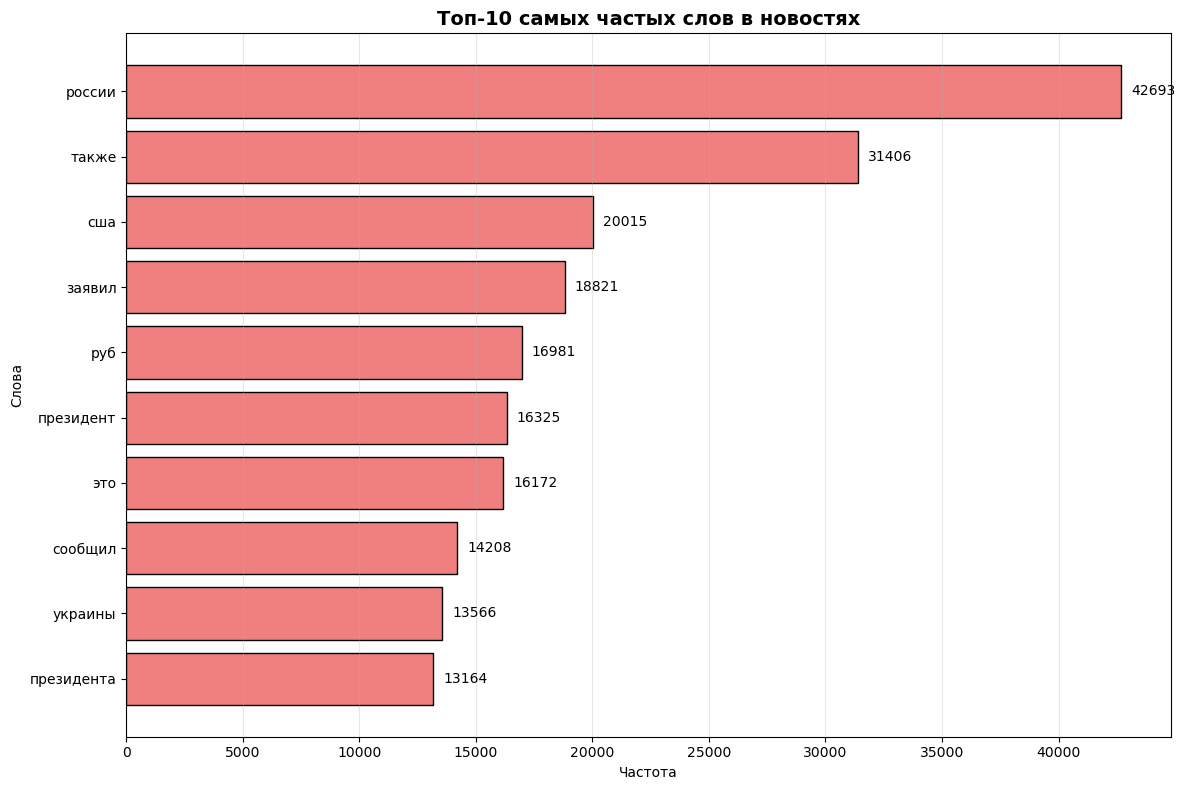

In [40]:
plot_top_words(df_vedomosti, 'text', top_n = 10)

# 3.3. Анализ новостей kommersant

In [41]:
df_kommersant.head(1)

,date,topic,text,heading
0,2022-05-01 14:55:00,economics,"Президент России Владимир Путин подписал закон, который позволит поддержать финансовую стабильность региональных и местных бюджетов в условиях санкций, в том числе путем выделения новых кредитов из федерального бюджета и реструктуризации или списания старых. Документ опубликован на официальном портале правовой информации. Согласно закону, в 2022 году из федерального бюджета российские субъекты получат кредиты в общей сумме до 390,7 млрд руб. С помощью этих средств планируется погасить долговые обязательства регионов и муниципалитетов по государственным и муниципальным ценным бумагам и коммерческим кредитам, чей срок погашения приходится на март-декабрь. Кредиты со сроком погашения до 2029 года под 0,1% годовых предоставят регионам, чей показатель уровня расчетной бюджетной обеспеченности на текущий год не превышает 1,5%. Первоначально предусматривалось, что из федерального бюджета регионам направят до 255,3 млрд руб. на погашение только долговых обязательств. Однако депутаты Госдумы во втором чтении поддержали поправку, предусматривающую использование таких кредитов и на погашение аналогичных муниципальных обязательств. В связи с этим общий объем бюджетных кредитов, предоставляемых регионам на соответствующие цели, увеличили на 134,5 млрд руб. Также документом предусмотрено предоставление в текущем году «казначейских» кредитов (на пополнение остатка средств на едином счете бюджета) для регионов в размере, не превышающем 10% утвержденных доходов их бюджетов, и с возвратом не позднее 30 декабря 2022 года. Правительство установит порядок и условия предоставления таких кредитов. Кроме прочего, регионы в текущем году освободят от исполнения обязательств по ранее реструктурированной задолженности по бюджетным кредитам. Ее погашение было решено перенести на 2029 год. В текущем году может быть реструктурирована или списана правительством задолженность по ранее не реструктурированным бюджетным кредитам на частичное покрытие дефицитов региональных бюджетов, срок погашения которых наступает в текущем году. Реструктуризация предусматривает, что задолженность по основному долгу и процентам по таким кредитам в 2022 году погашению не подлежит. С 2023 по 2024 год погасят ежегодно по 5% суммы задолженности, а с 2025 по 2029 год — ежегодно равными долями от остатка задолженности с возможностью досрочного погашения. В закон была внесена поправка, предусматривающая перенос с текущего года на 2025 год погашения задолженности по основному долгу и процентам по бюджетным кредитам для Тамбовской и Псковской областей, Республики Марий Эл и Приморского края, что позволит регионам присоединиться к реструктуризации.",Путин подписал закон о дополнительной поддержке регионов в условиях санкций


In [42]:
df_kommersant.duplicated().sum()

0

In [43]:
df_kommersant.isna().sum()

date       0
topic      0
text       0
heading    0
dtype: int64

In [44]:
df_kommersant.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20971 entries, 0 to 20970
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   date     20971 non-null  object
 1   topic    20971 non-null  object
 2   text     20971 non-null  object
 3   heading  20971 non-null  object
dtypes: object(4)
memory usage: 655.5+ KB


**Вывод:** Дубликаты и пропуски в данных отстутствуют.

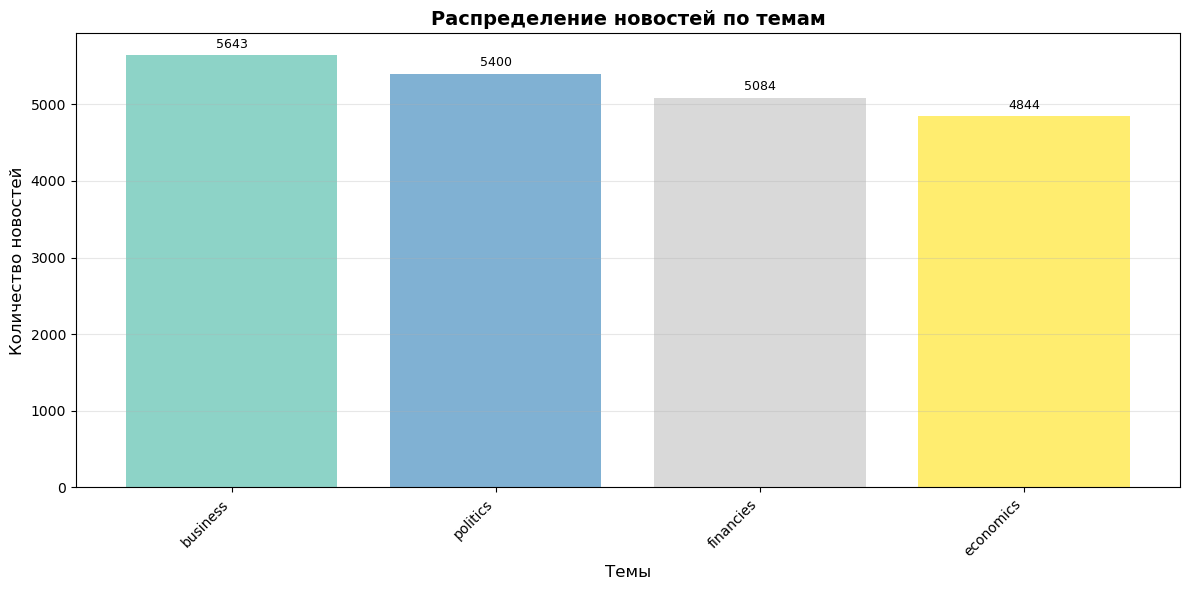

In [45]:
plot_topic_barchart(df_kommersant, 'topic')

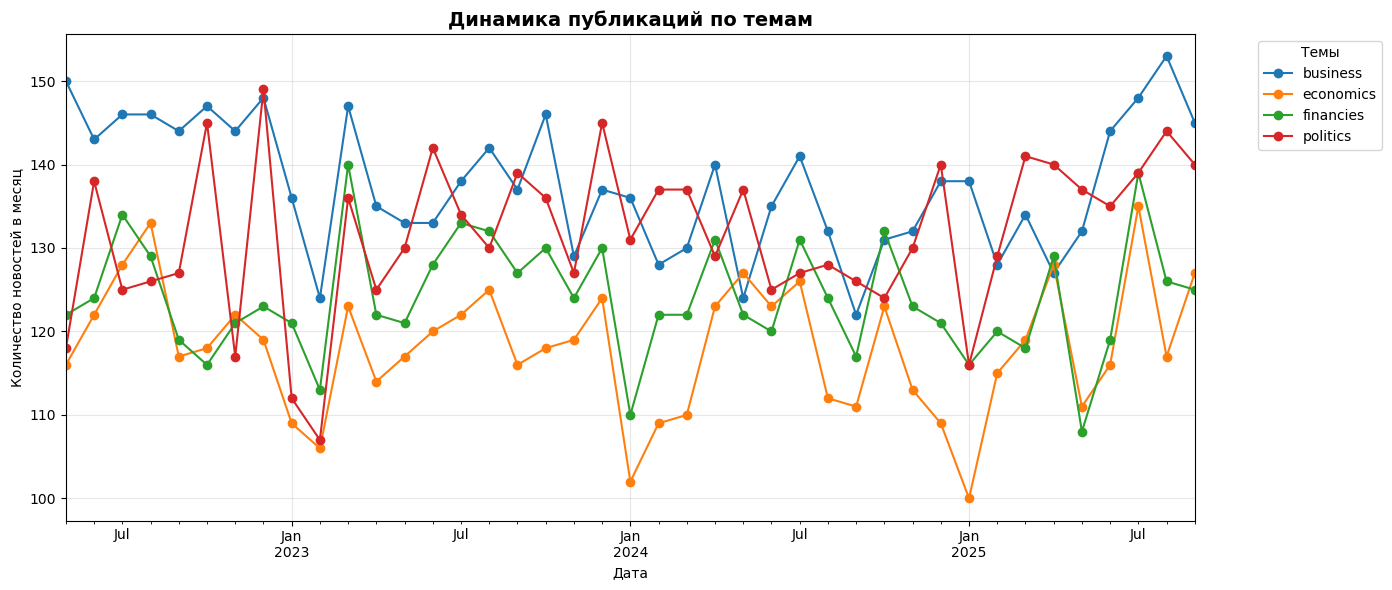

In [46]:
plot_topic_timeseries(df_kommersant, 'topic', 'date', top_n = 4)

**Вывод:** Распределение тем равномерное. Динамика публикаций стабильная, резких скачков нет.

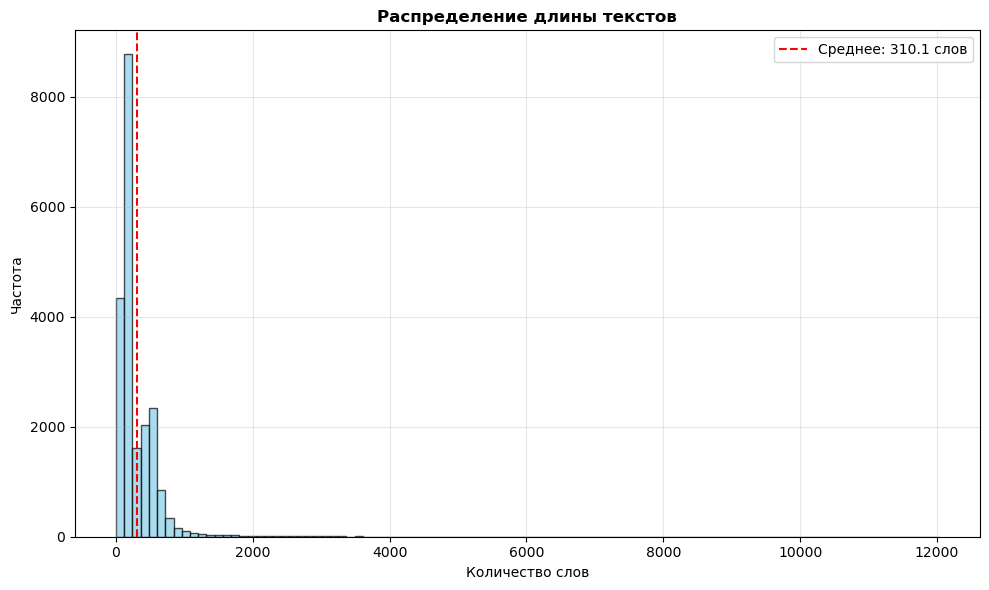

In [47]:
plot_word_count_distribution(df_kommersant, 'text')

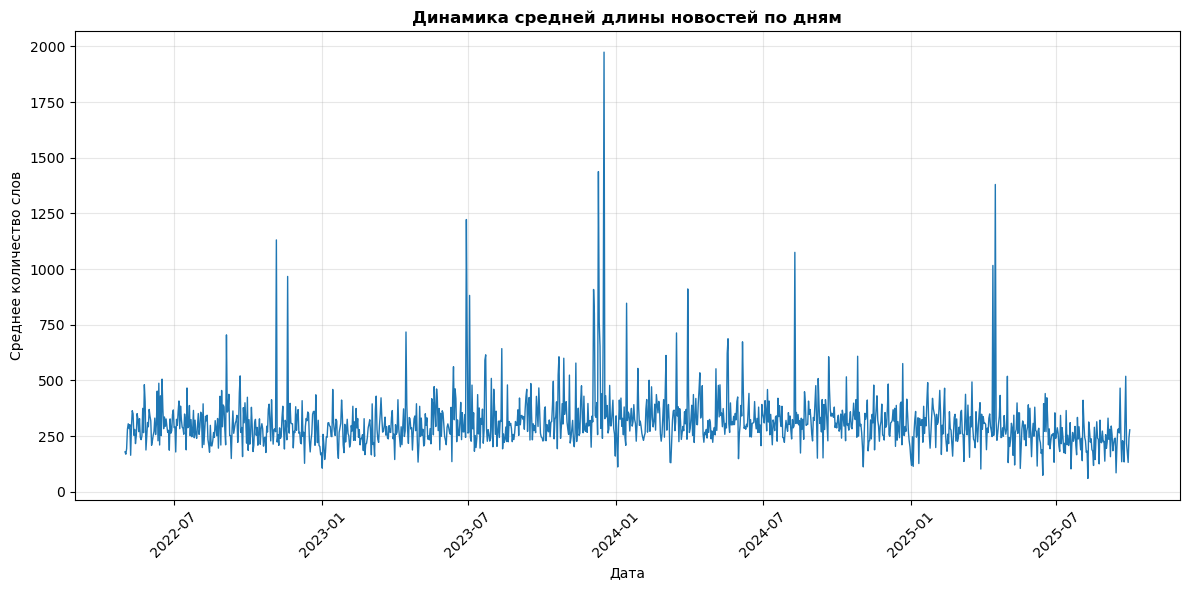

In [48]:
plot_daily_word_length_evolution(df_kommersant, 'text', 'date')

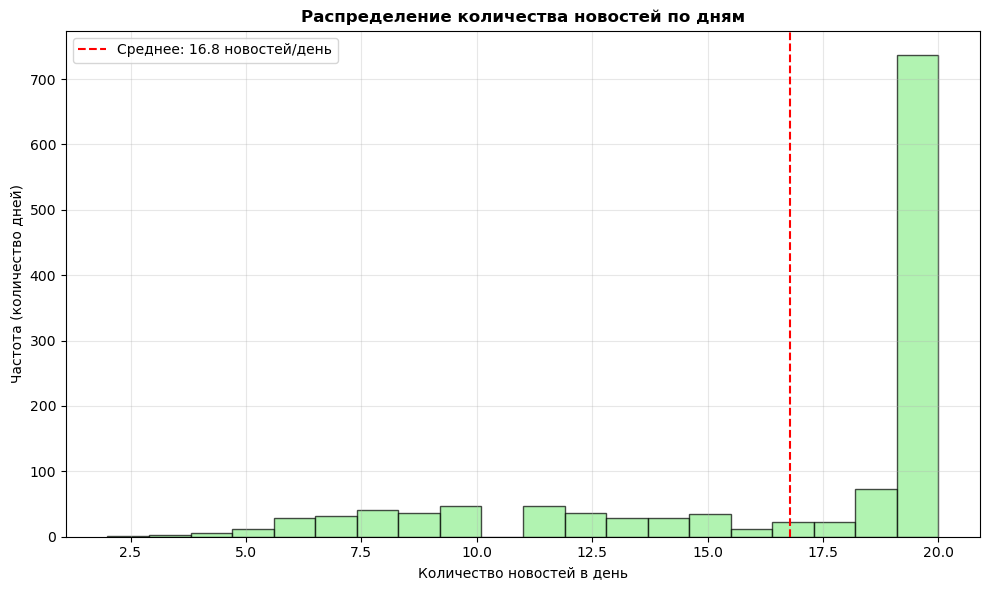

In [49]:
plot_news_count_distribution(df_kommersant, 'date')

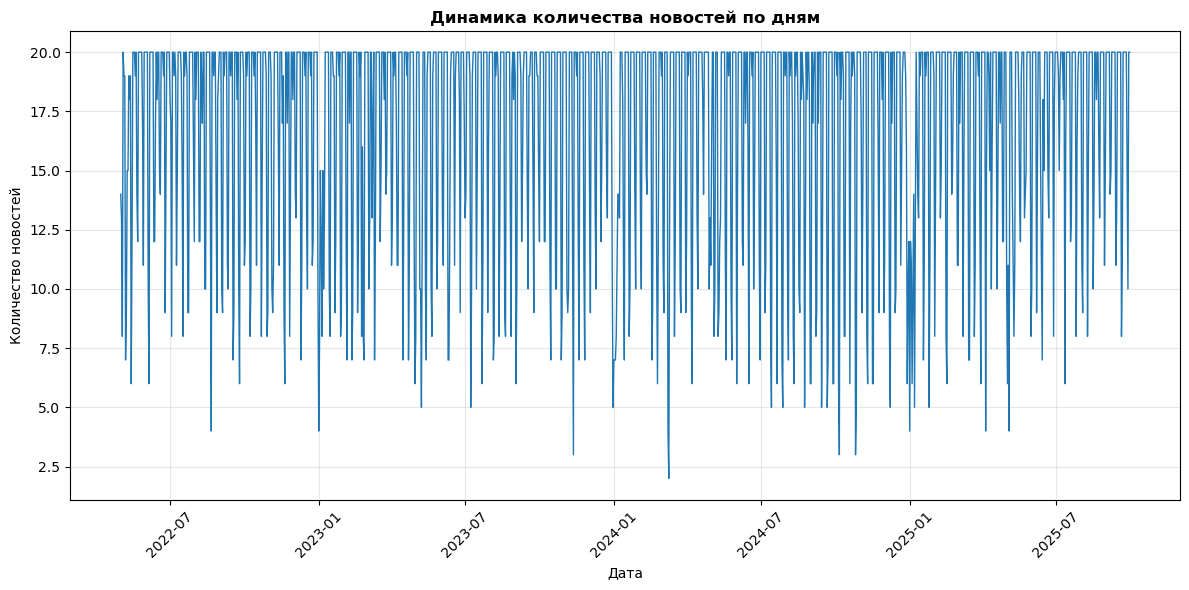

In [50]:
plot_daily_news_count_evolution(df_kommersant, 'date')

**Вывод:** В данном источнике в среднем новости содержат около 310 слов. В целом, их длина стабильна, однако имеются аномально большие значения, которые было принято решение удалить из-за потенциальных трудностей работы с ними. Кроме этого, количество новостей выпускаемых в день ограничивается строго числом 20. Была обнаружена проблема парсинга данных, считывалось максимум по 5 новостей в день по каждой теме из-за особенностей источника, поэтому было принято решение дополнить данные и посмотреть на их изменение.

In [51]:
df_kommersant = pd.read_csv('data/news_kommersant.csv').drop('url', axis = 1)
df_kommersant['text'] = df_kommersant['text'].apply(lambda x: '.'.join(x.split('.')[:-2]) + '.')
df_kommersant = df_kommersant[(df_kommersant['date'] >= start_date) & (df_kommersant['date'] <= end_date)].reset_index(drop = True)
df_kommersant.head(1)

,date,topic,text,heading
0,2022-05-01 14:55:00,economics,"Президент России Владимир Путин подписал закон, который позволит поддержать финансовую стабильность региональных и местных бюджетов в условиях санкций, в том числе путем выделения новых кредитов из федерального бюджета и реструктуризации или списания старых. Документ опубликован на официальном портале правовой информации. Согласно закону, в 2022 году из федерального бюджета российские субъекты получат кредиты в общей сумме до 390,7 млрд руб. С помощью этих средств планируется погасить долговые обязательства регионов и муниципалитетов по государственным и муниципальным ценным бумагам и коммерческим кредитам, чей срок погашения приходится на март-декабрь. Кредиты со сроком погашения до 2029 года под 0,1% годовых предоставят регионам, чей показатель уровня расчетной бюджетной обеспеченности на текущий год не превышает 1,5%. Первоначально предусматривалось, что из федерального бюджета регионам направят до 255,3 млрд руб. на погашение только долговых обязательств. Однако депутаты Госдумы во втором чтении поддержали поправку, предусматривающую использование таких кредитов и на погашение аналогичных муниципальных обязательств. В связи с этим общий объем бюджетных кредитов, предоставляемых регионам на соответствующие цели, увеличили на 134,5 млрд руб. Также документом предусмотрено предоставление в текущем году «казначейских» кредитов (на пополнение остатка средств на едином счете бюджета) для регионов в размере, не превышающем 10% утвержденных доходов их бюджетов, и с возвратом не позднее 30 декабря 2022 года. Правительство установит порядок и условия предоставления таких кредитов. Кроме прочего, регионы в текущем году освободят от исполнения обязательств по ранее реструктурированной задолженности по бюджетным кредитам. Ее погашение было решено перенести на 2029 год. В текущем году может быть реструктурирована или списана правительством задолженность по ранее не реструктурированным бюджетным кредитам на частичное покрытие дефицитов региональных бюджетов, срок погашения которых наступает в текущем году. Реструктуризация предусматривает, что задолженность по основному долгу и процентам по таким кредитам в 2022 году погашению не подлежит. С 2023 по 2024 год погасят ежегодно по 5% суммы задолженности, а с 2025 по 2029 год — ежегодно равными долями от остатка задолженности с возможностью досрочного погашения. В закон была внесена поправка, предусматривающая перенос с текущего года на 2025 год погашения задолженности по основному долгу и процентам по бюджетным кредитам для Тамбовской и Псковской областей, Республики Марий Эл и Приморского края, что позволит регионам присоединиться к реструктуризации.",Путин подписал закон о дополнительной поддержке регионов в условиях санкций


In [52]:
df_kommersant.duplicated().sum()

5096

In [53]:
df_kommersant.drop_duplicates(inplace = True)

In [54]:
df_kommersant.isna().sum()

date       0
topic      0
text       0
heading    0
dtype: int64

**Вывод:** В данных имелось много дубликатов, которые было принято решение удалить, пропуски отстутствуют.

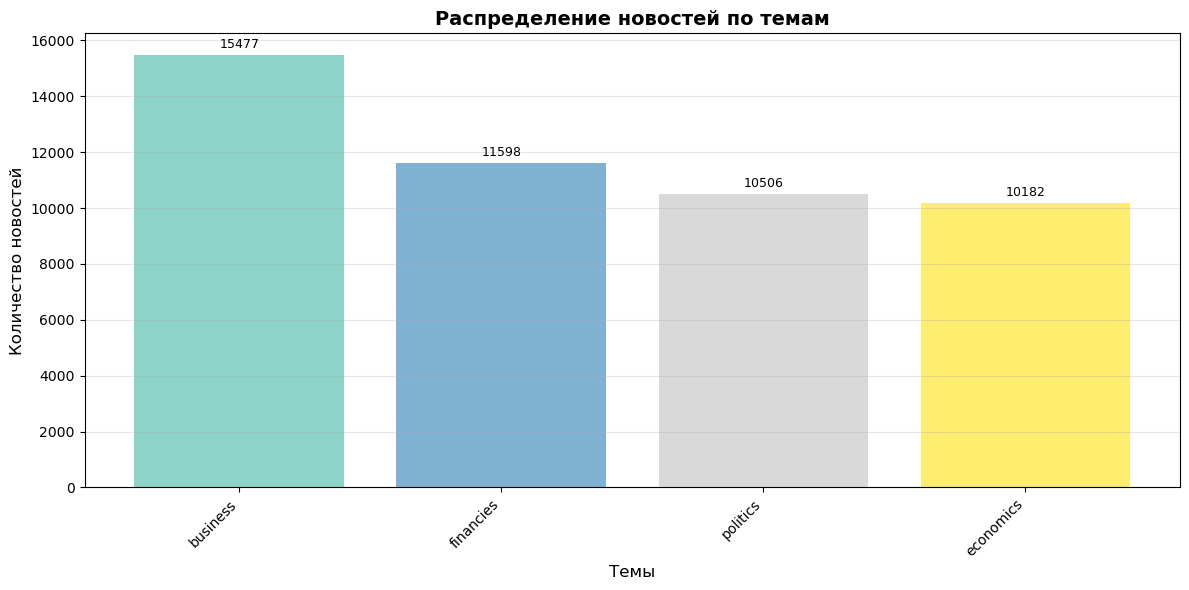

In [55]:
plot_topic_barchart(df_kommersant, 'topic')

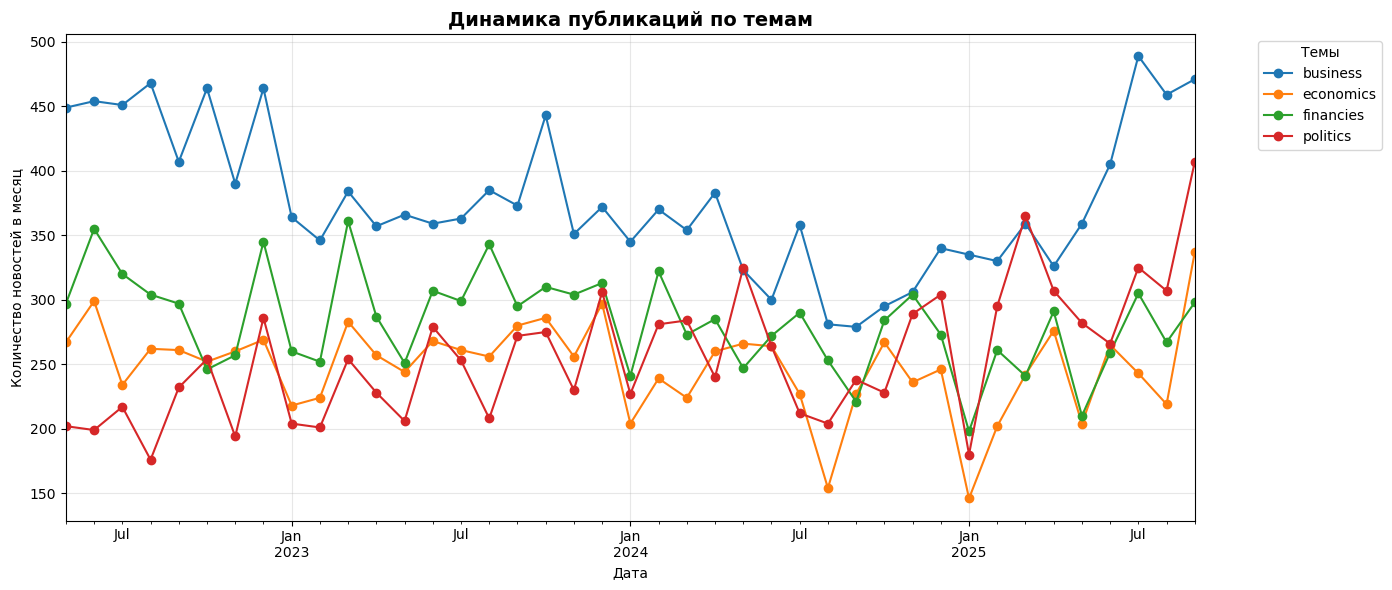

In [56]:
plot_topic_timeseries(df_kommersant, 'topic', 'date', top_n = 4)

**Вывод:** После дополнения данных ситуация изменилась, теперь можно выделить преобладающий класс новостей, связанных с бизнесом, все остальные темы, в целом, распределены равномерно.

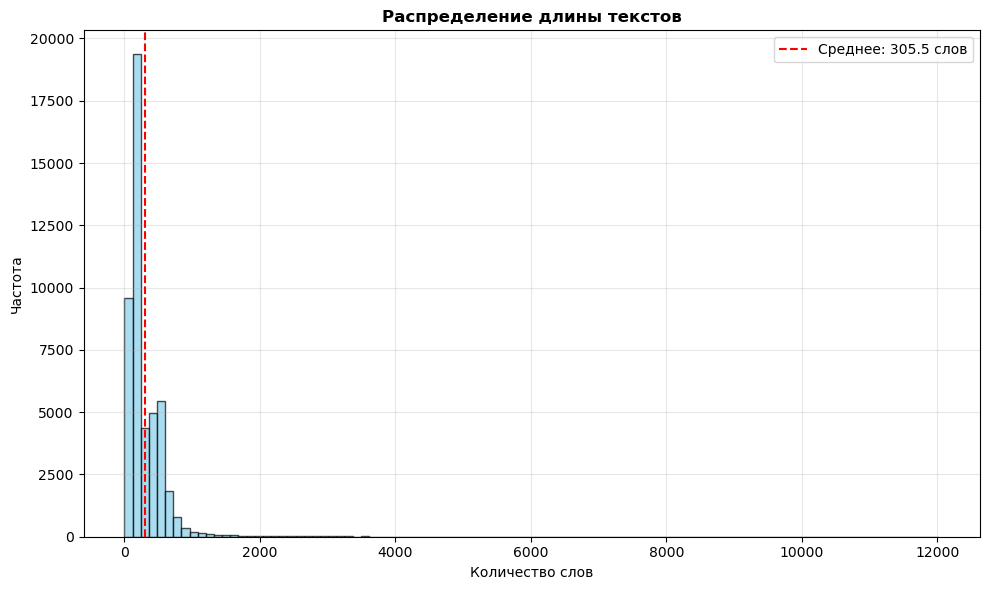

In [57]:
plot_word_count_distribution(df_kommersant, 'text')

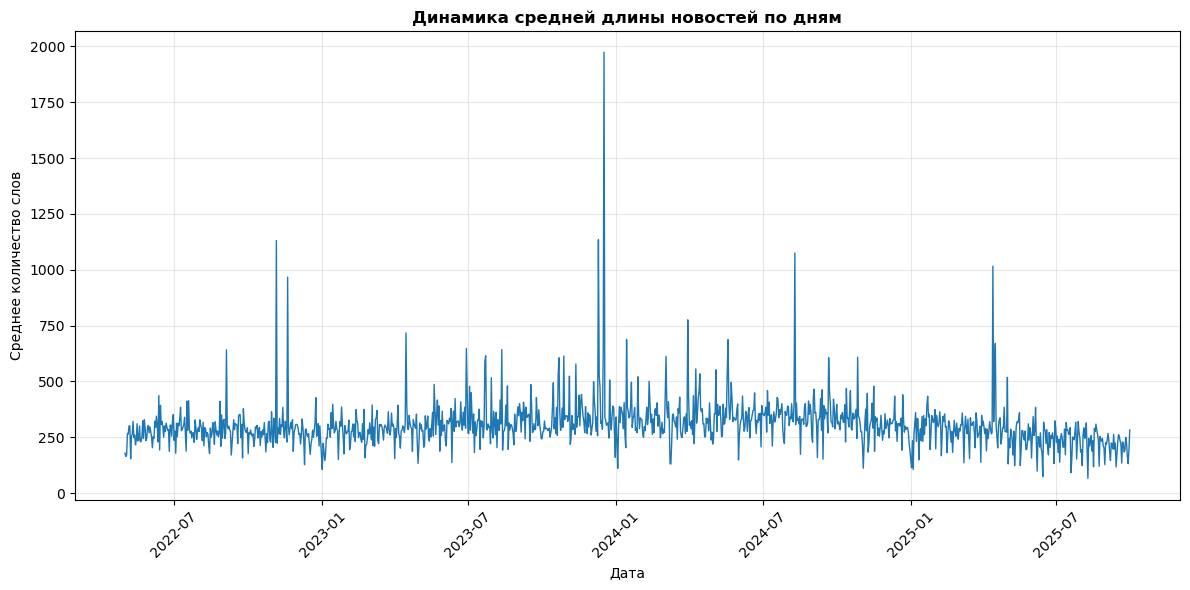

In [58]:
plot_daily_word_length_evolution(df_kommersant, 'text', 'date')

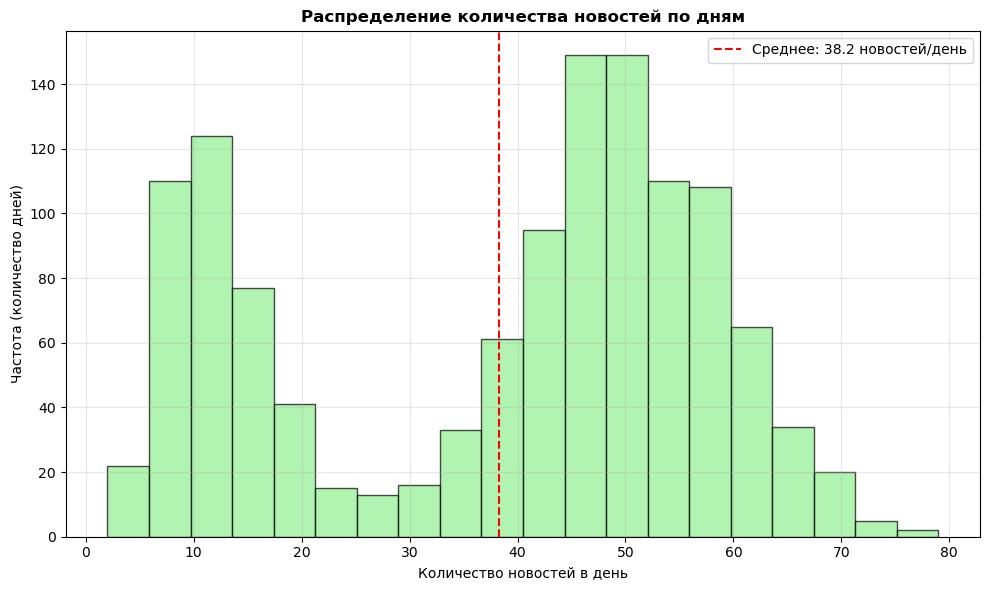

In [59]:
plot_news_count_distribution(df_kommersant, 'date')

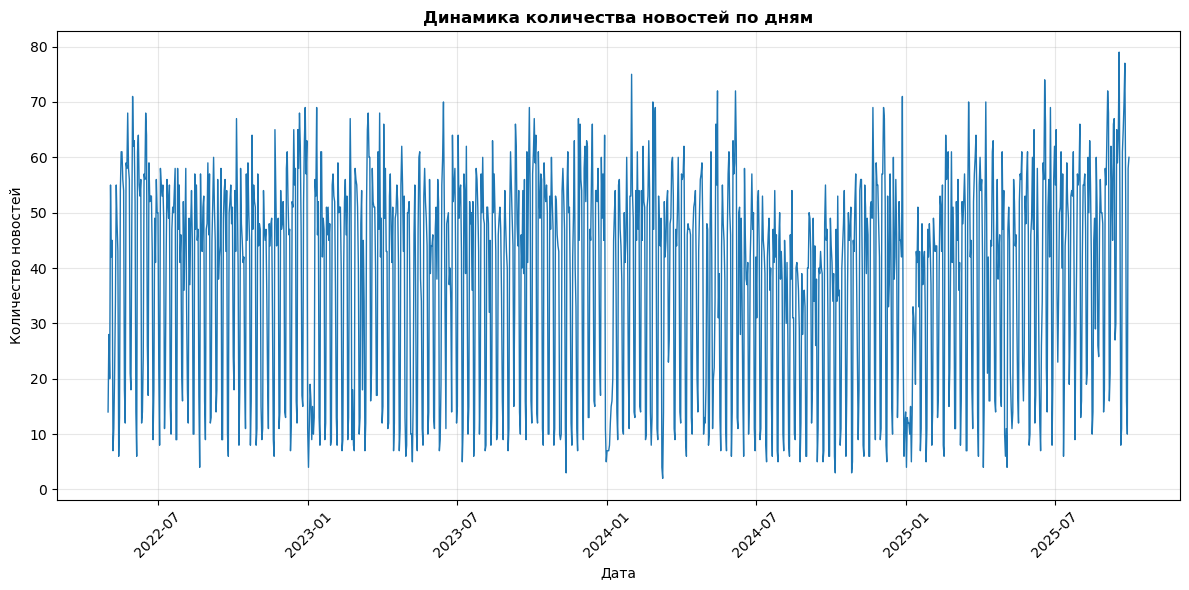

In [60]:
plot_daily_news_count_evolution(df_kommersant, 'date')

**Выводы:** Наличие аномальных значений в длине новостей не изменилось, поэтому произведём их удаление. Динамика публикаций схожа со случаем новостей interfax, а именно, имеется много дней, где количество новостей резко падает, что может говорить и непостоянстве источника.

In [61]:
df_kommersant = df_kommersant[df_kommersant['text'].str.split().str.len() <= 1000].reset_index(drop = True)

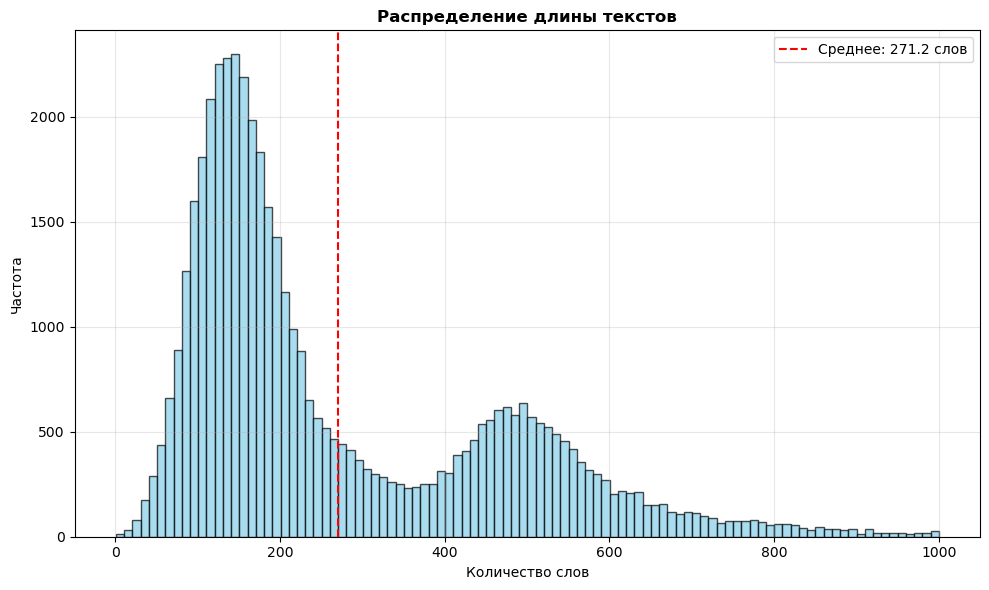

In [62]:
plot_word_count_distribution(df_kommersant, 'text')

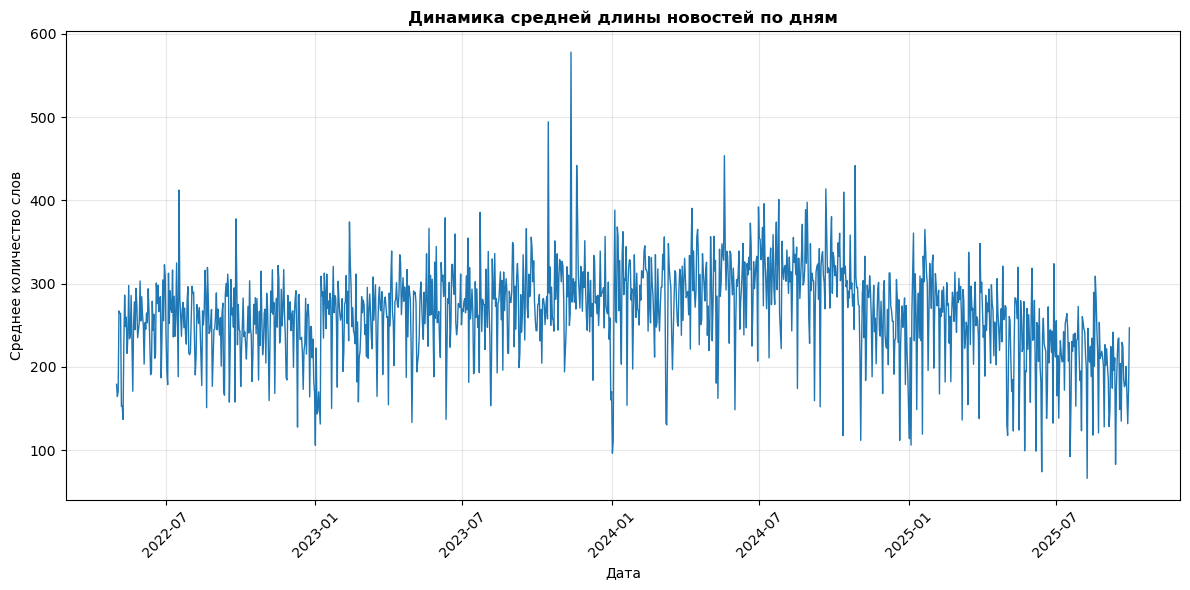

In [64]:
plot_daily_word_length_evolution(df_kommersant, 'text', 'date')

**Вывод:** После удаления аномальных значений распределение и динамика заметно улучшились, средняя длина стала около 270 слов.

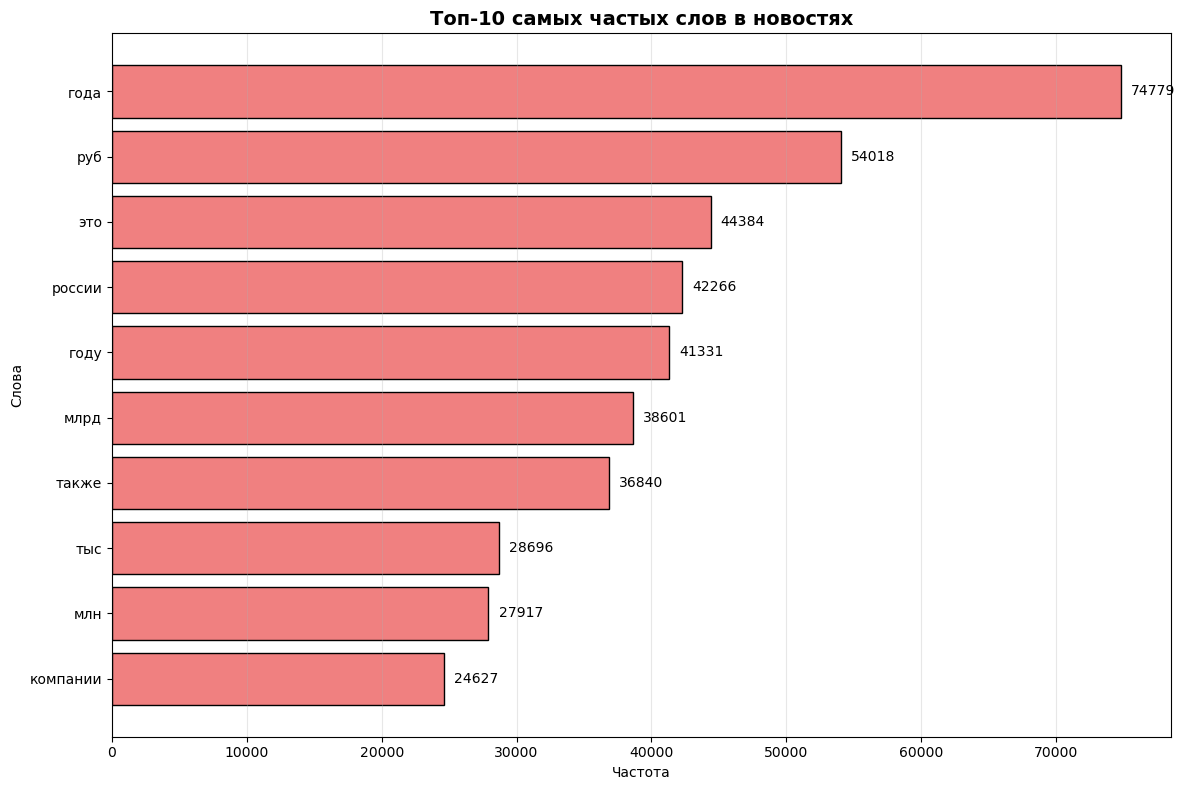

In [65]:
plot_top_words(df_kommersant, 'text', top_n = 10)

# 4. Сохранение финальных данных

In [66]:
df_interfax.to_csv('data/news_interfax_final.csv', index = False, encoding = 'utf-8')
df_vedomosti.to_csv('data/news_vedomosti_final.csv', index = False, encoding = 'utf-8')
df_kommersant.to_csv('data/news_kommersant_final.csv', index = False, encoding = 'utf-8')